#***HR Attrition Prediction***

**🧠 Problem Statement**

Employee attrition is a critical issue for organizations, leading to increased hiring costs,
productivity loss, and reduced employee morale.
In this project, the goal is to build a Machine Learning classification model that predicts
whether an employee will leave the company (Attrition: Yes/No) based on features such as:
● Age
● Salary
● Job Role
● Job Satisfaction
● Work Experience
● Overtime
● Work-Life Balance
● Department






#***🎯 Objective***

The objective of this task is to:
● Understand and explore the HR dataset
● Perform data preprocessing (missing values, duplicates, outliers)
● Conduct Exploratory Data Analysis (EDA)
● Apply encoding and feature scaling
● Train multiple classification algorithms
● Evaluate models using classification metrics
● Perform cross-validation and hyperparameter tuning
● Select the best-performing model

#**📌 Tasks**

In [1]:
#import all required libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv('HR-Employee-Attrition.csv')

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.shape

(1470, 35)

In [5]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [9]:
df.duplicated().sum()

np.int64(0)

### <span style="color: #1a73e8;">Data Preprocessing</span>

In [10]:
df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'], inplace=True)
df.shape

(1470, 31)

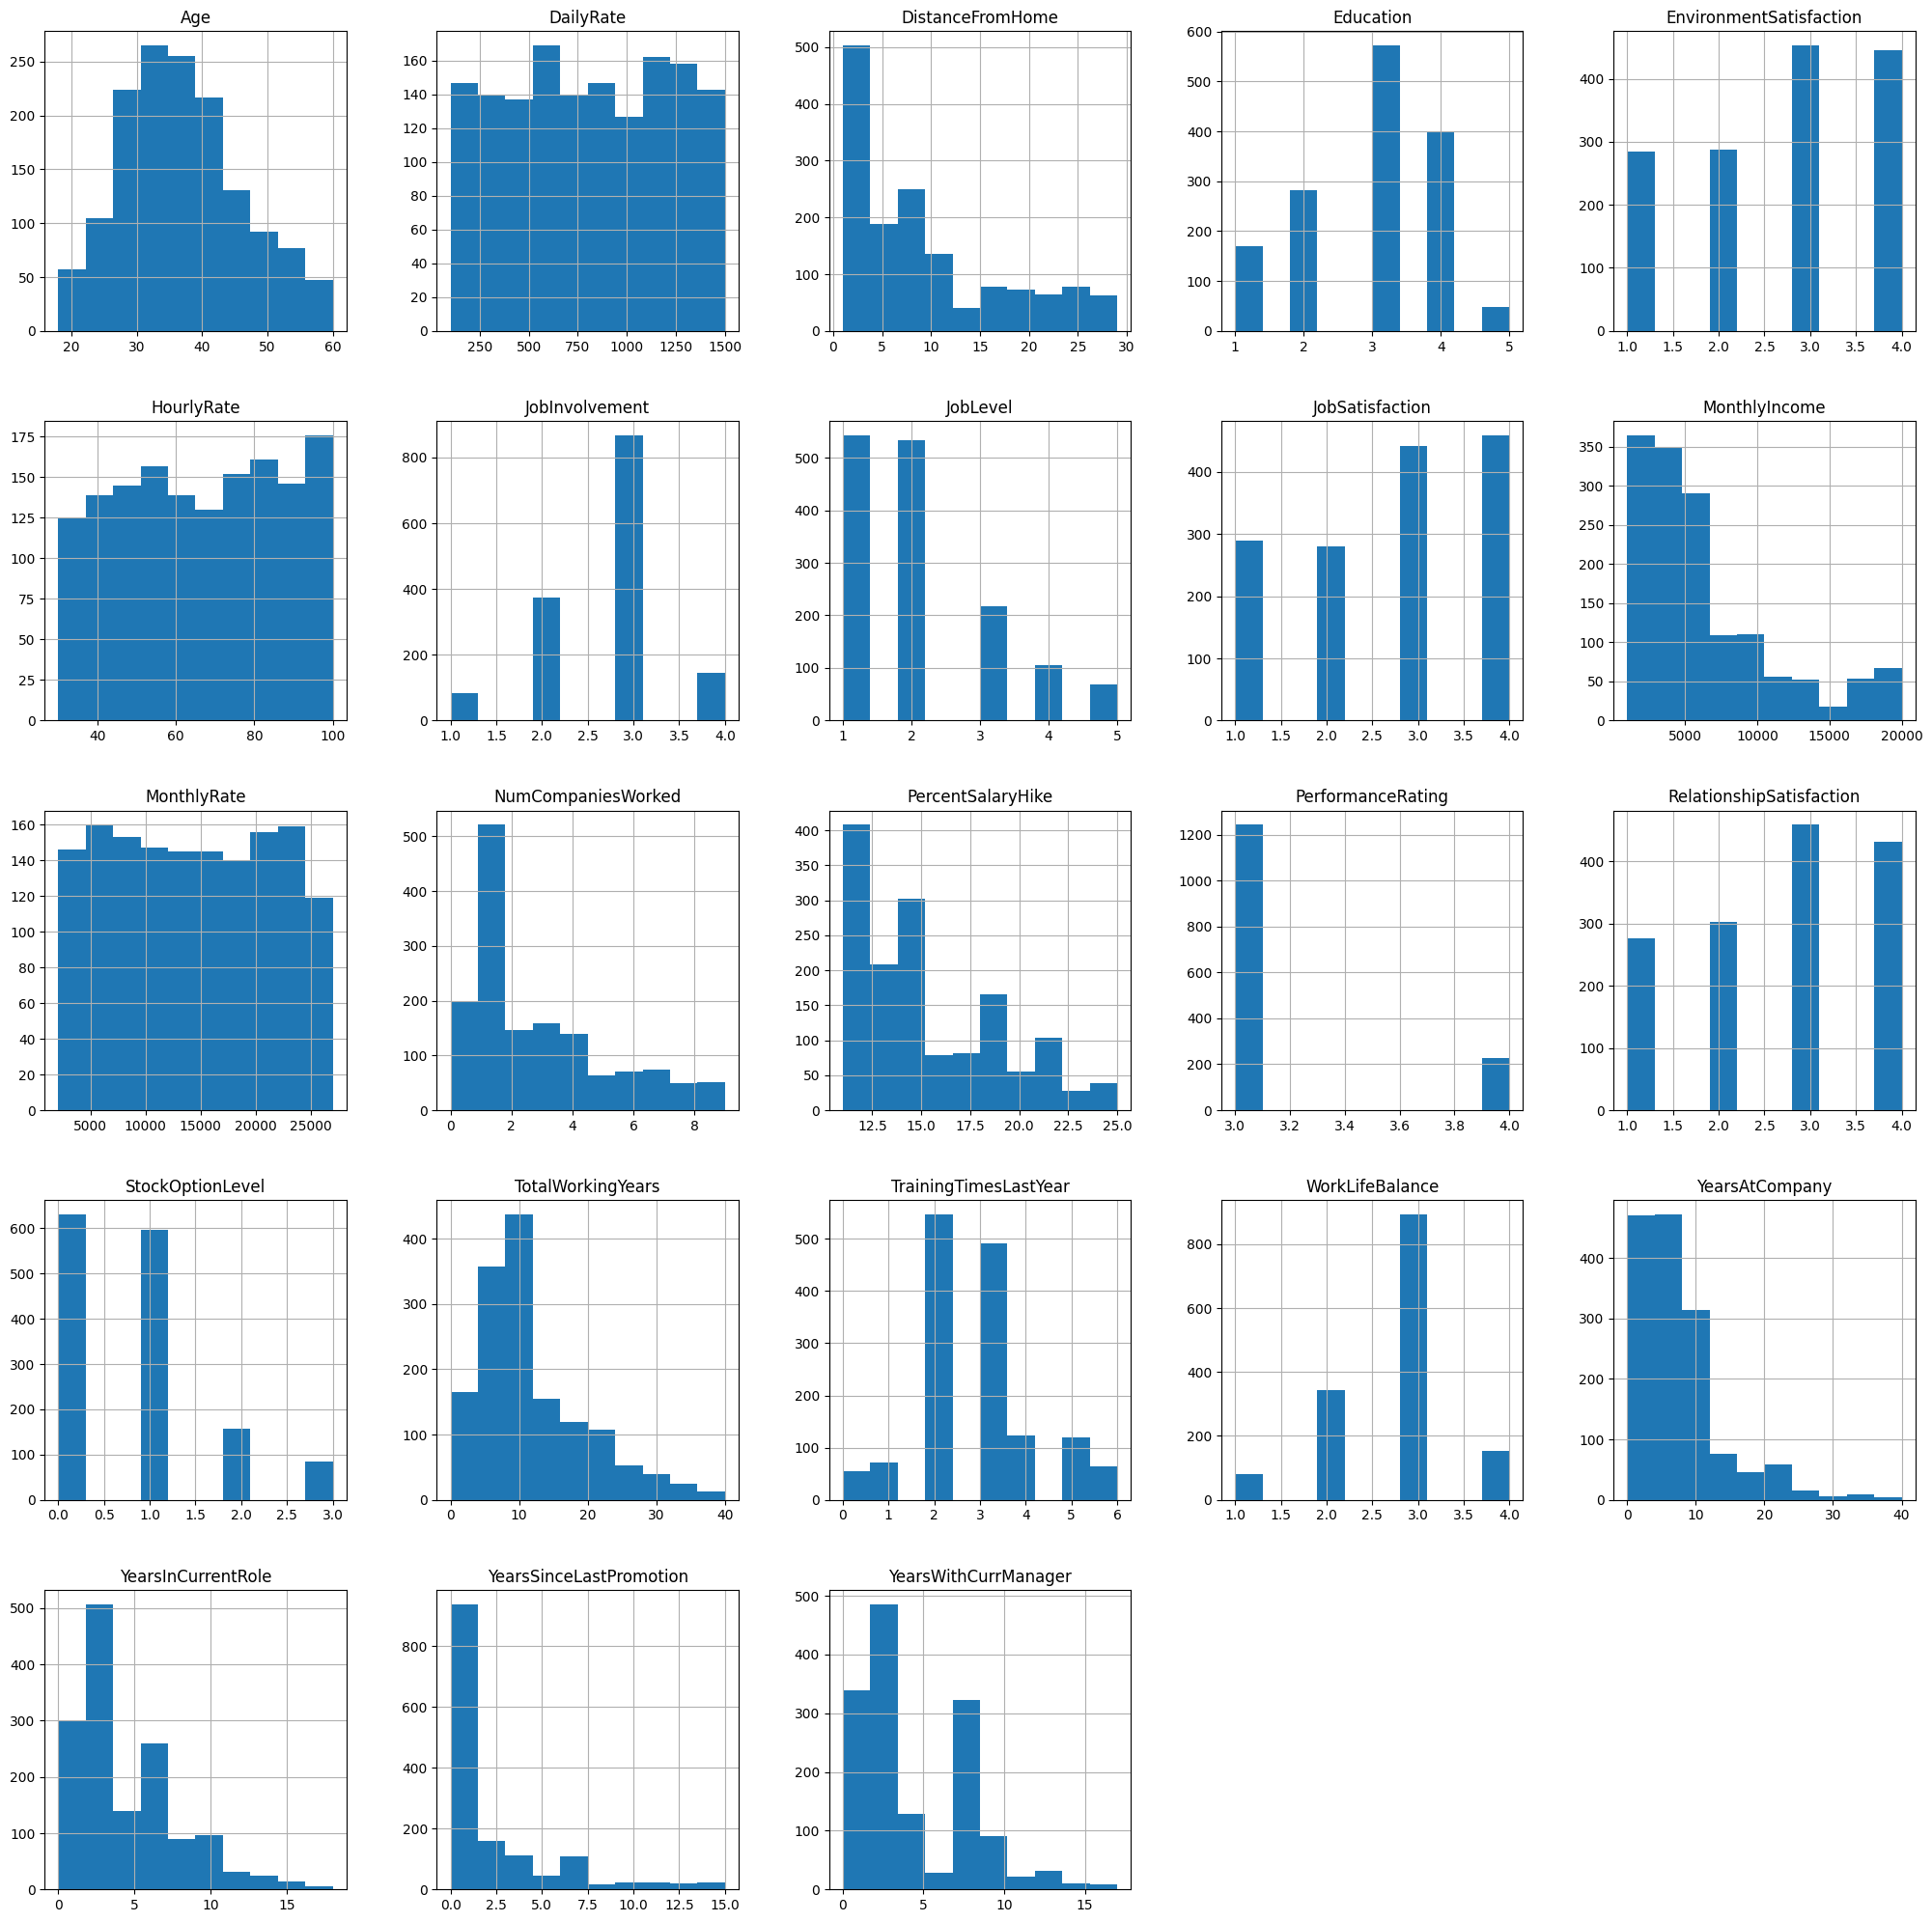

In [25]:
df.hist(figsize=(25,25))
plt.show()

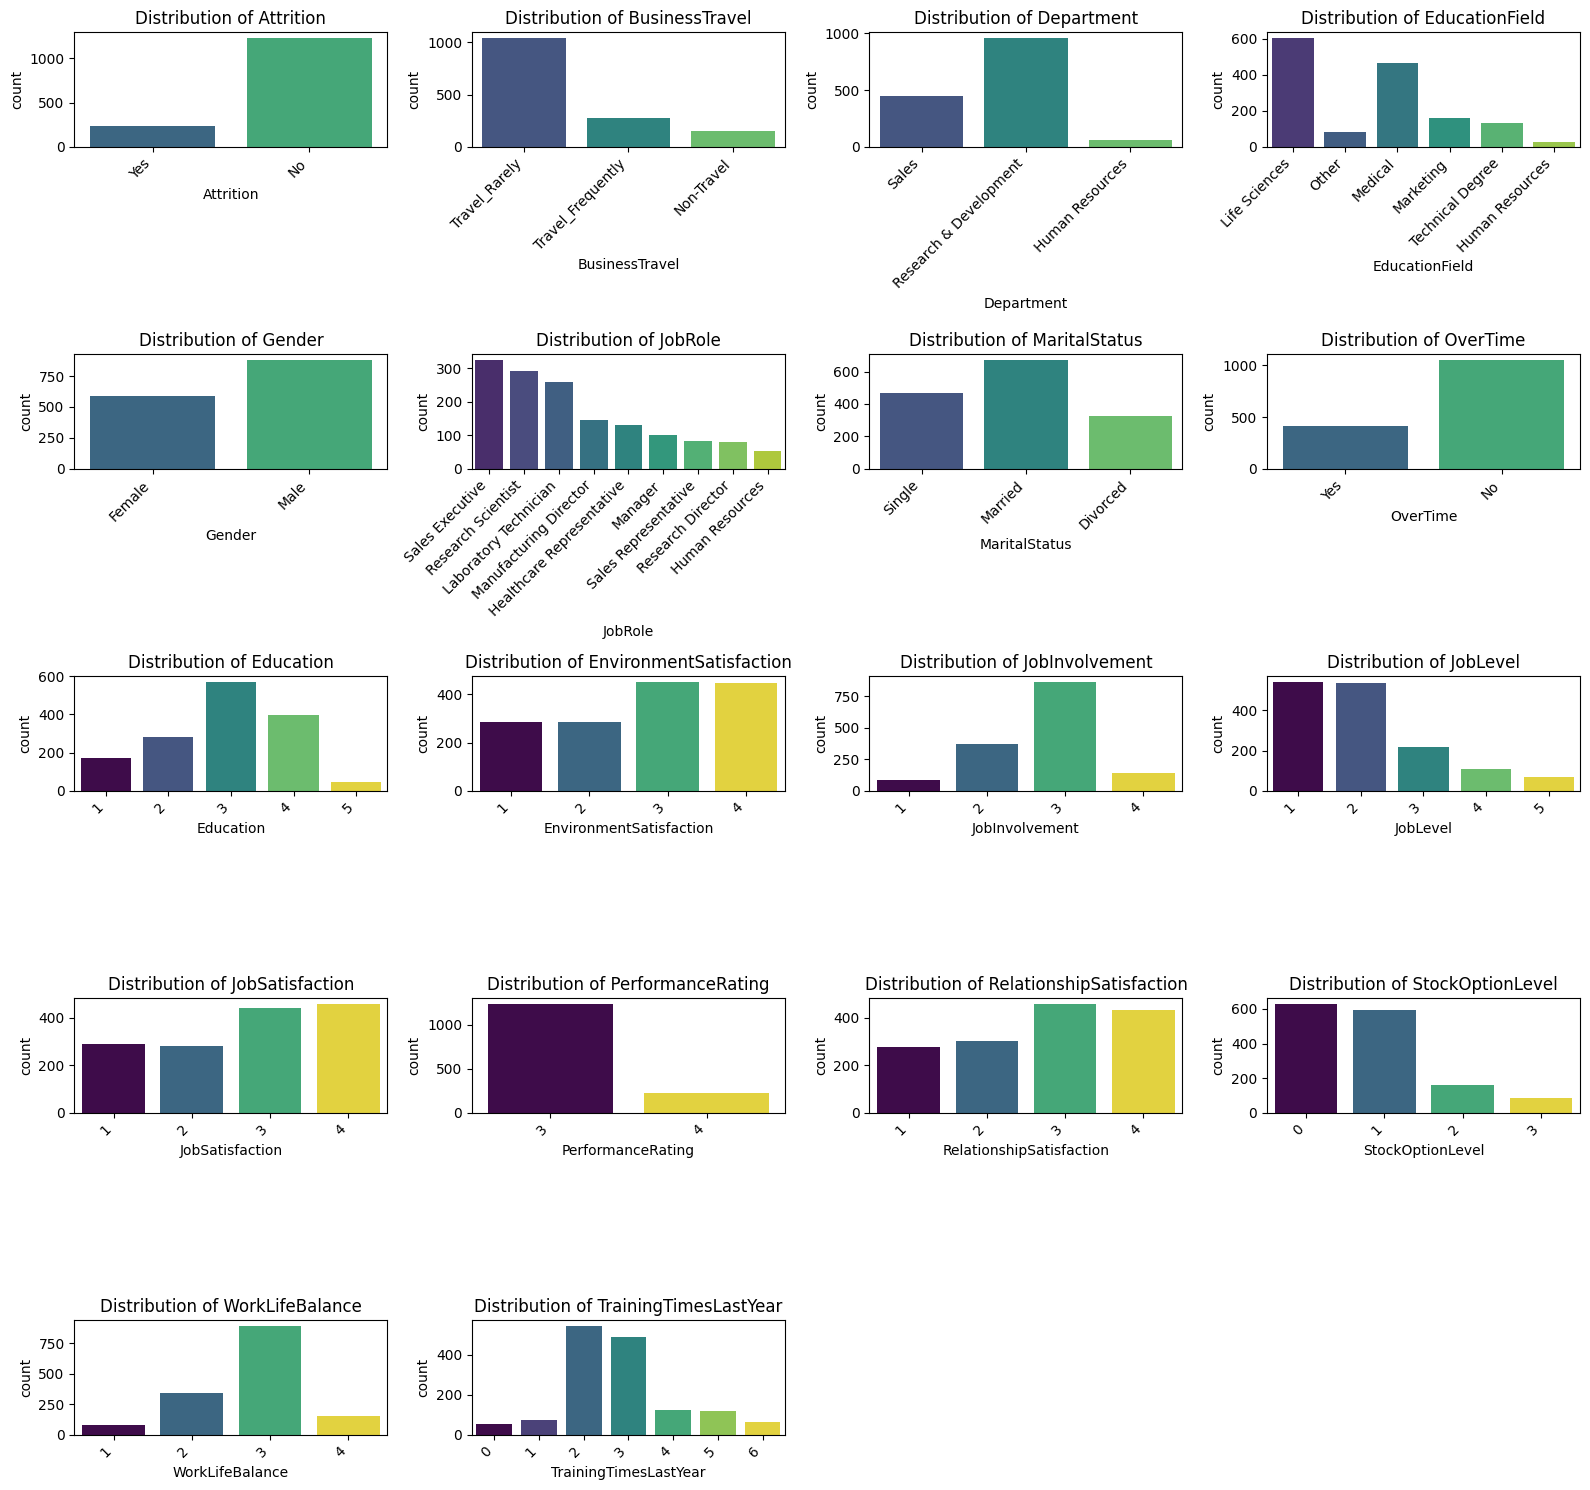

In [12]:


categorical_cols = [
    'Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
    'JobRole', 'MaritalStatus', 'OverTime', 'Education',
    'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
    'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
    'WorkLifeBalance', 'TrainingTimesLastYear'
]

# Determine the number of rows and columns for the subplots
num_cols = 4
num_rows = (len(categorical_cols) + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 4, num_rows * 3))

for i, col in enumerate(categorical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.countplot(x=col, data=df, palette='viridis', hue=col, legend=False)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

plt.show()

In [13]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

### <span style="color: #1a73e8;">Bivariate Analysis: Attrition vs. Categorical Features</span>

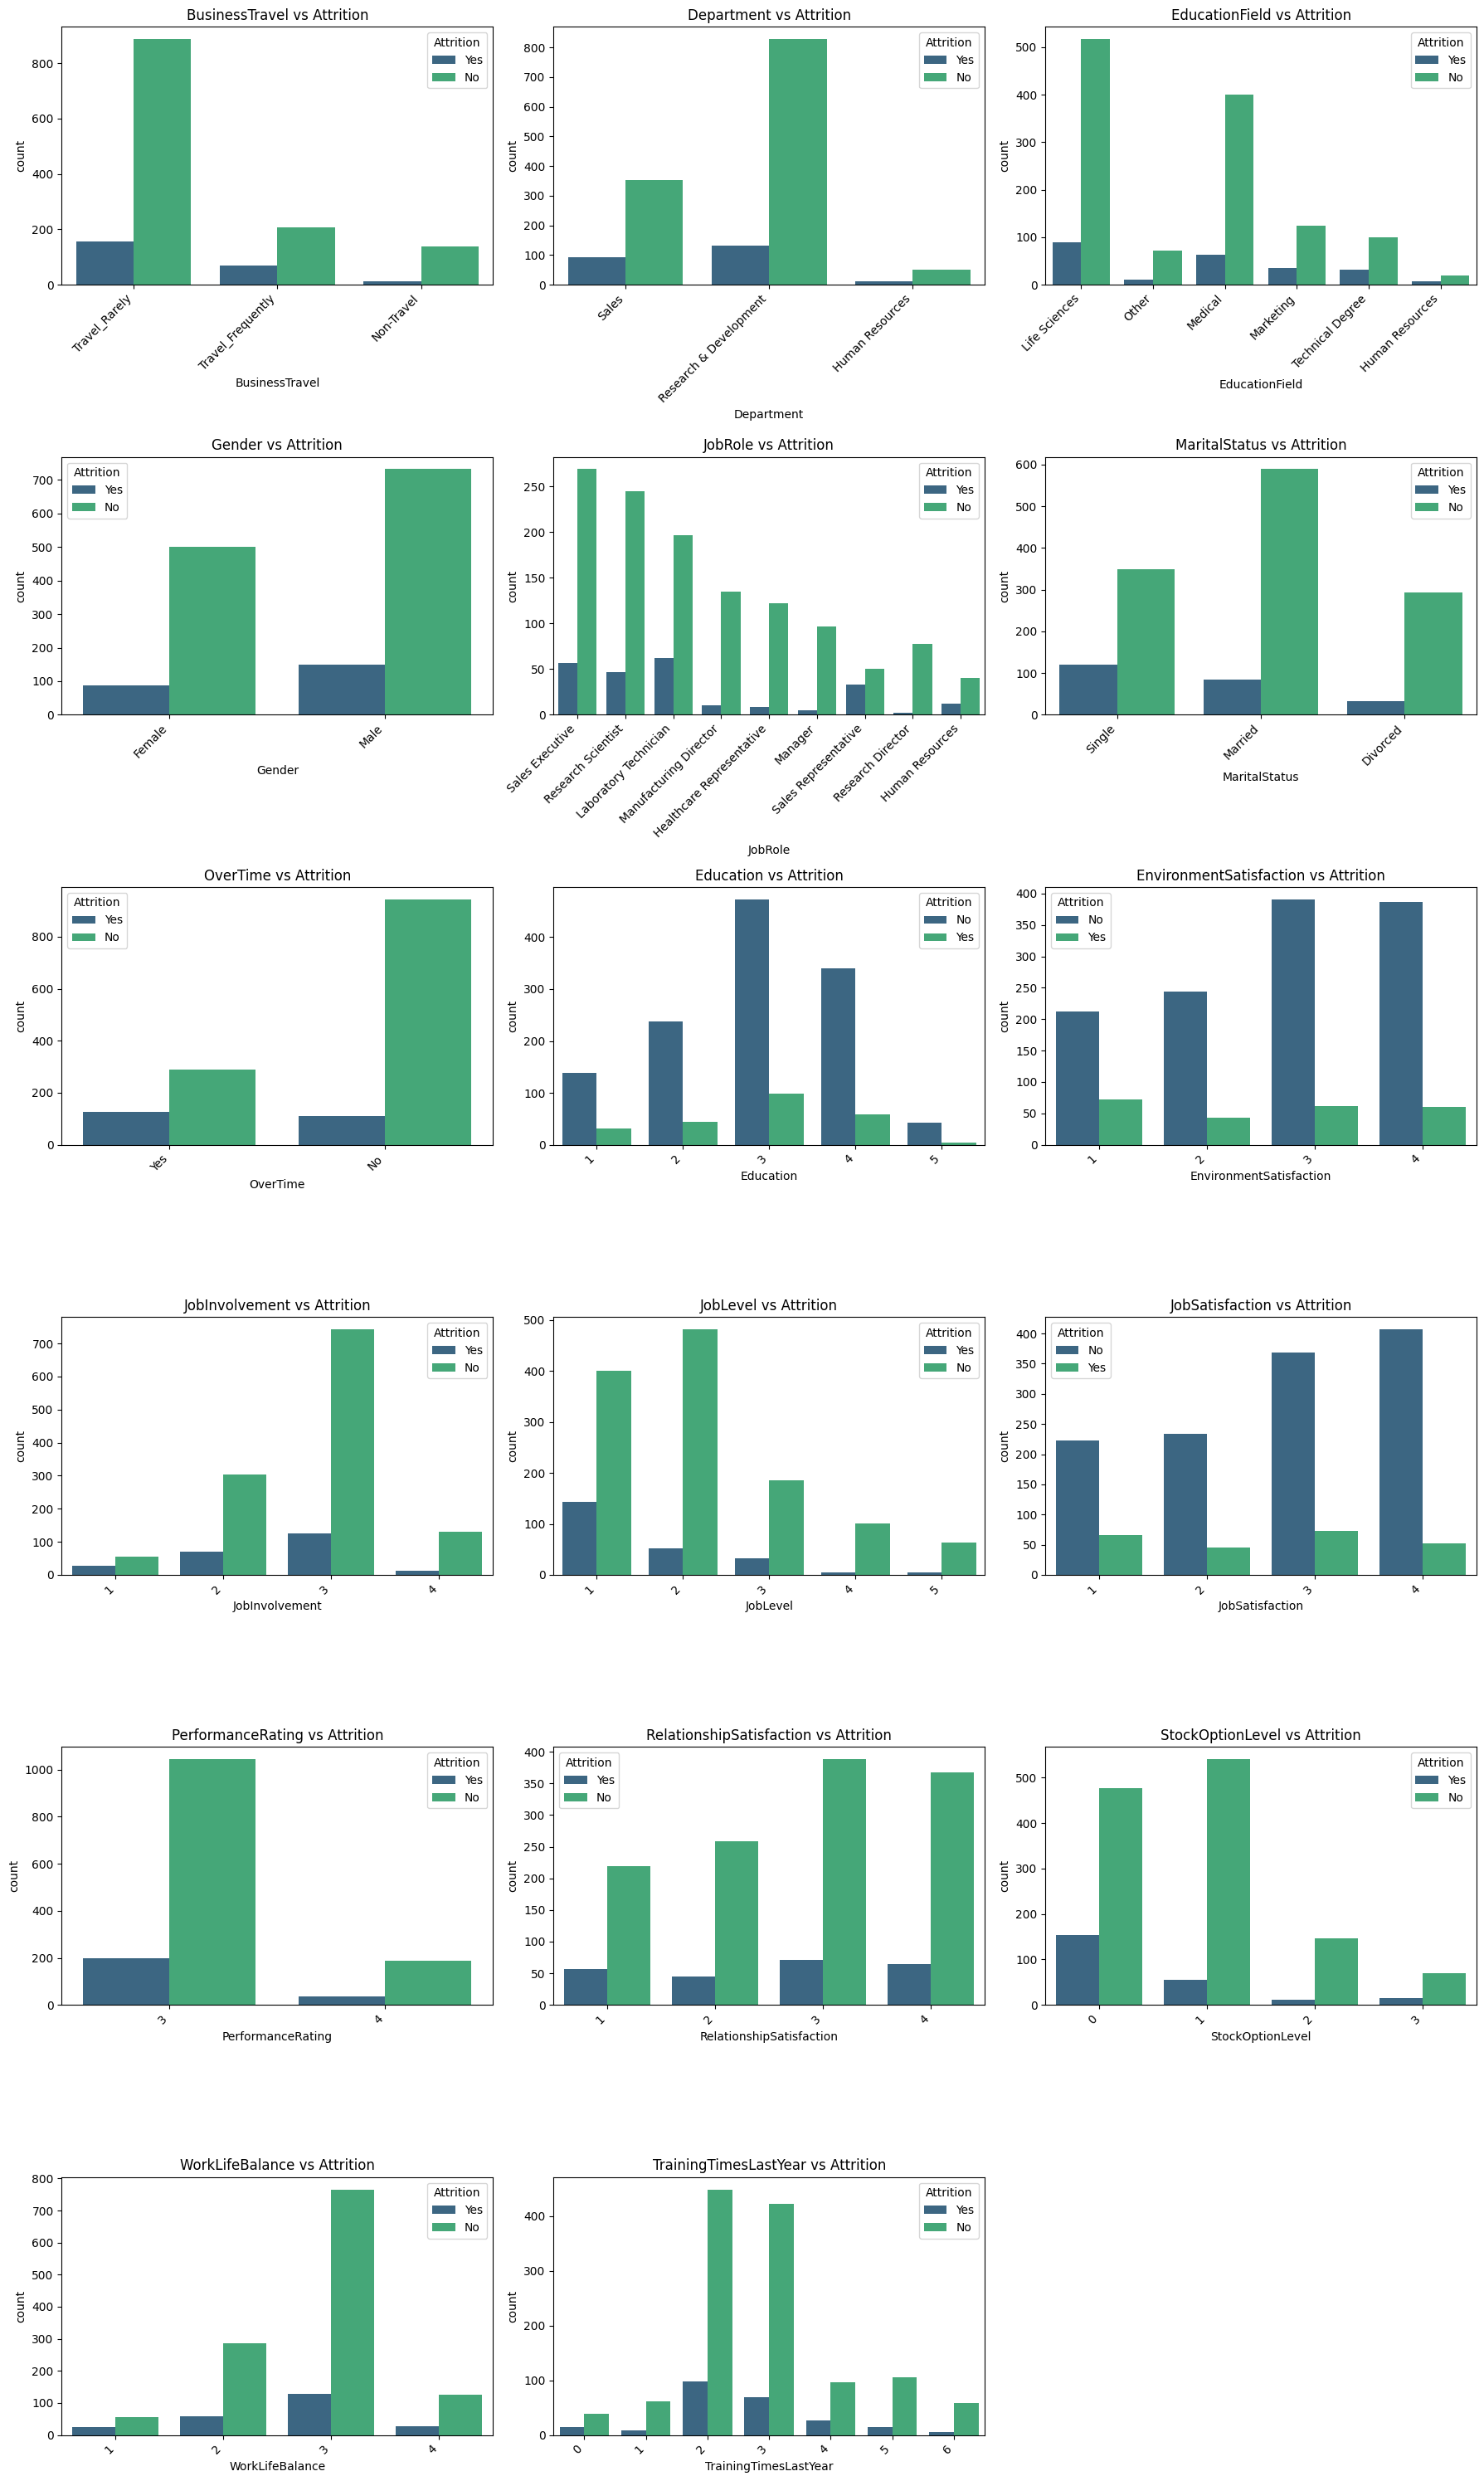

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features_bivariate = [
    'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
    'MaritalStatus', 'OverTime', 'Education', 'EnvironmentSatisfaction',
    'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating',
    'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance',
    'TrainingTimesLastYear'
]

num_cols = 3
num_rows = (len(categorical_features_bivariate) + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 6, num_rows * 5))

for i, col in enumerate(categorical_features_bivariate):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.countplot(x=col, hue='Attrition', data=df, palette='viridis')
    plt.title(f'{col} vs Attrition')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

plt.show()

### <span style="color: #1a73e8;">Bivariate Analysis: Attrition vs. Numerical Features</span>

/tmp/ipykernel_28231/2040313498.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Attrition', x=col, data=df, palette='viridis')
/tmp/ipykernel_28231/2040313498.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Attrition', x=col, data=df, palette='viridis')
/tmp/ipykernel_28231/2040313498.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Attrition', x=col, data=df, palette='viridis')
/tmp/ipykernel_28231/2040313498.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0

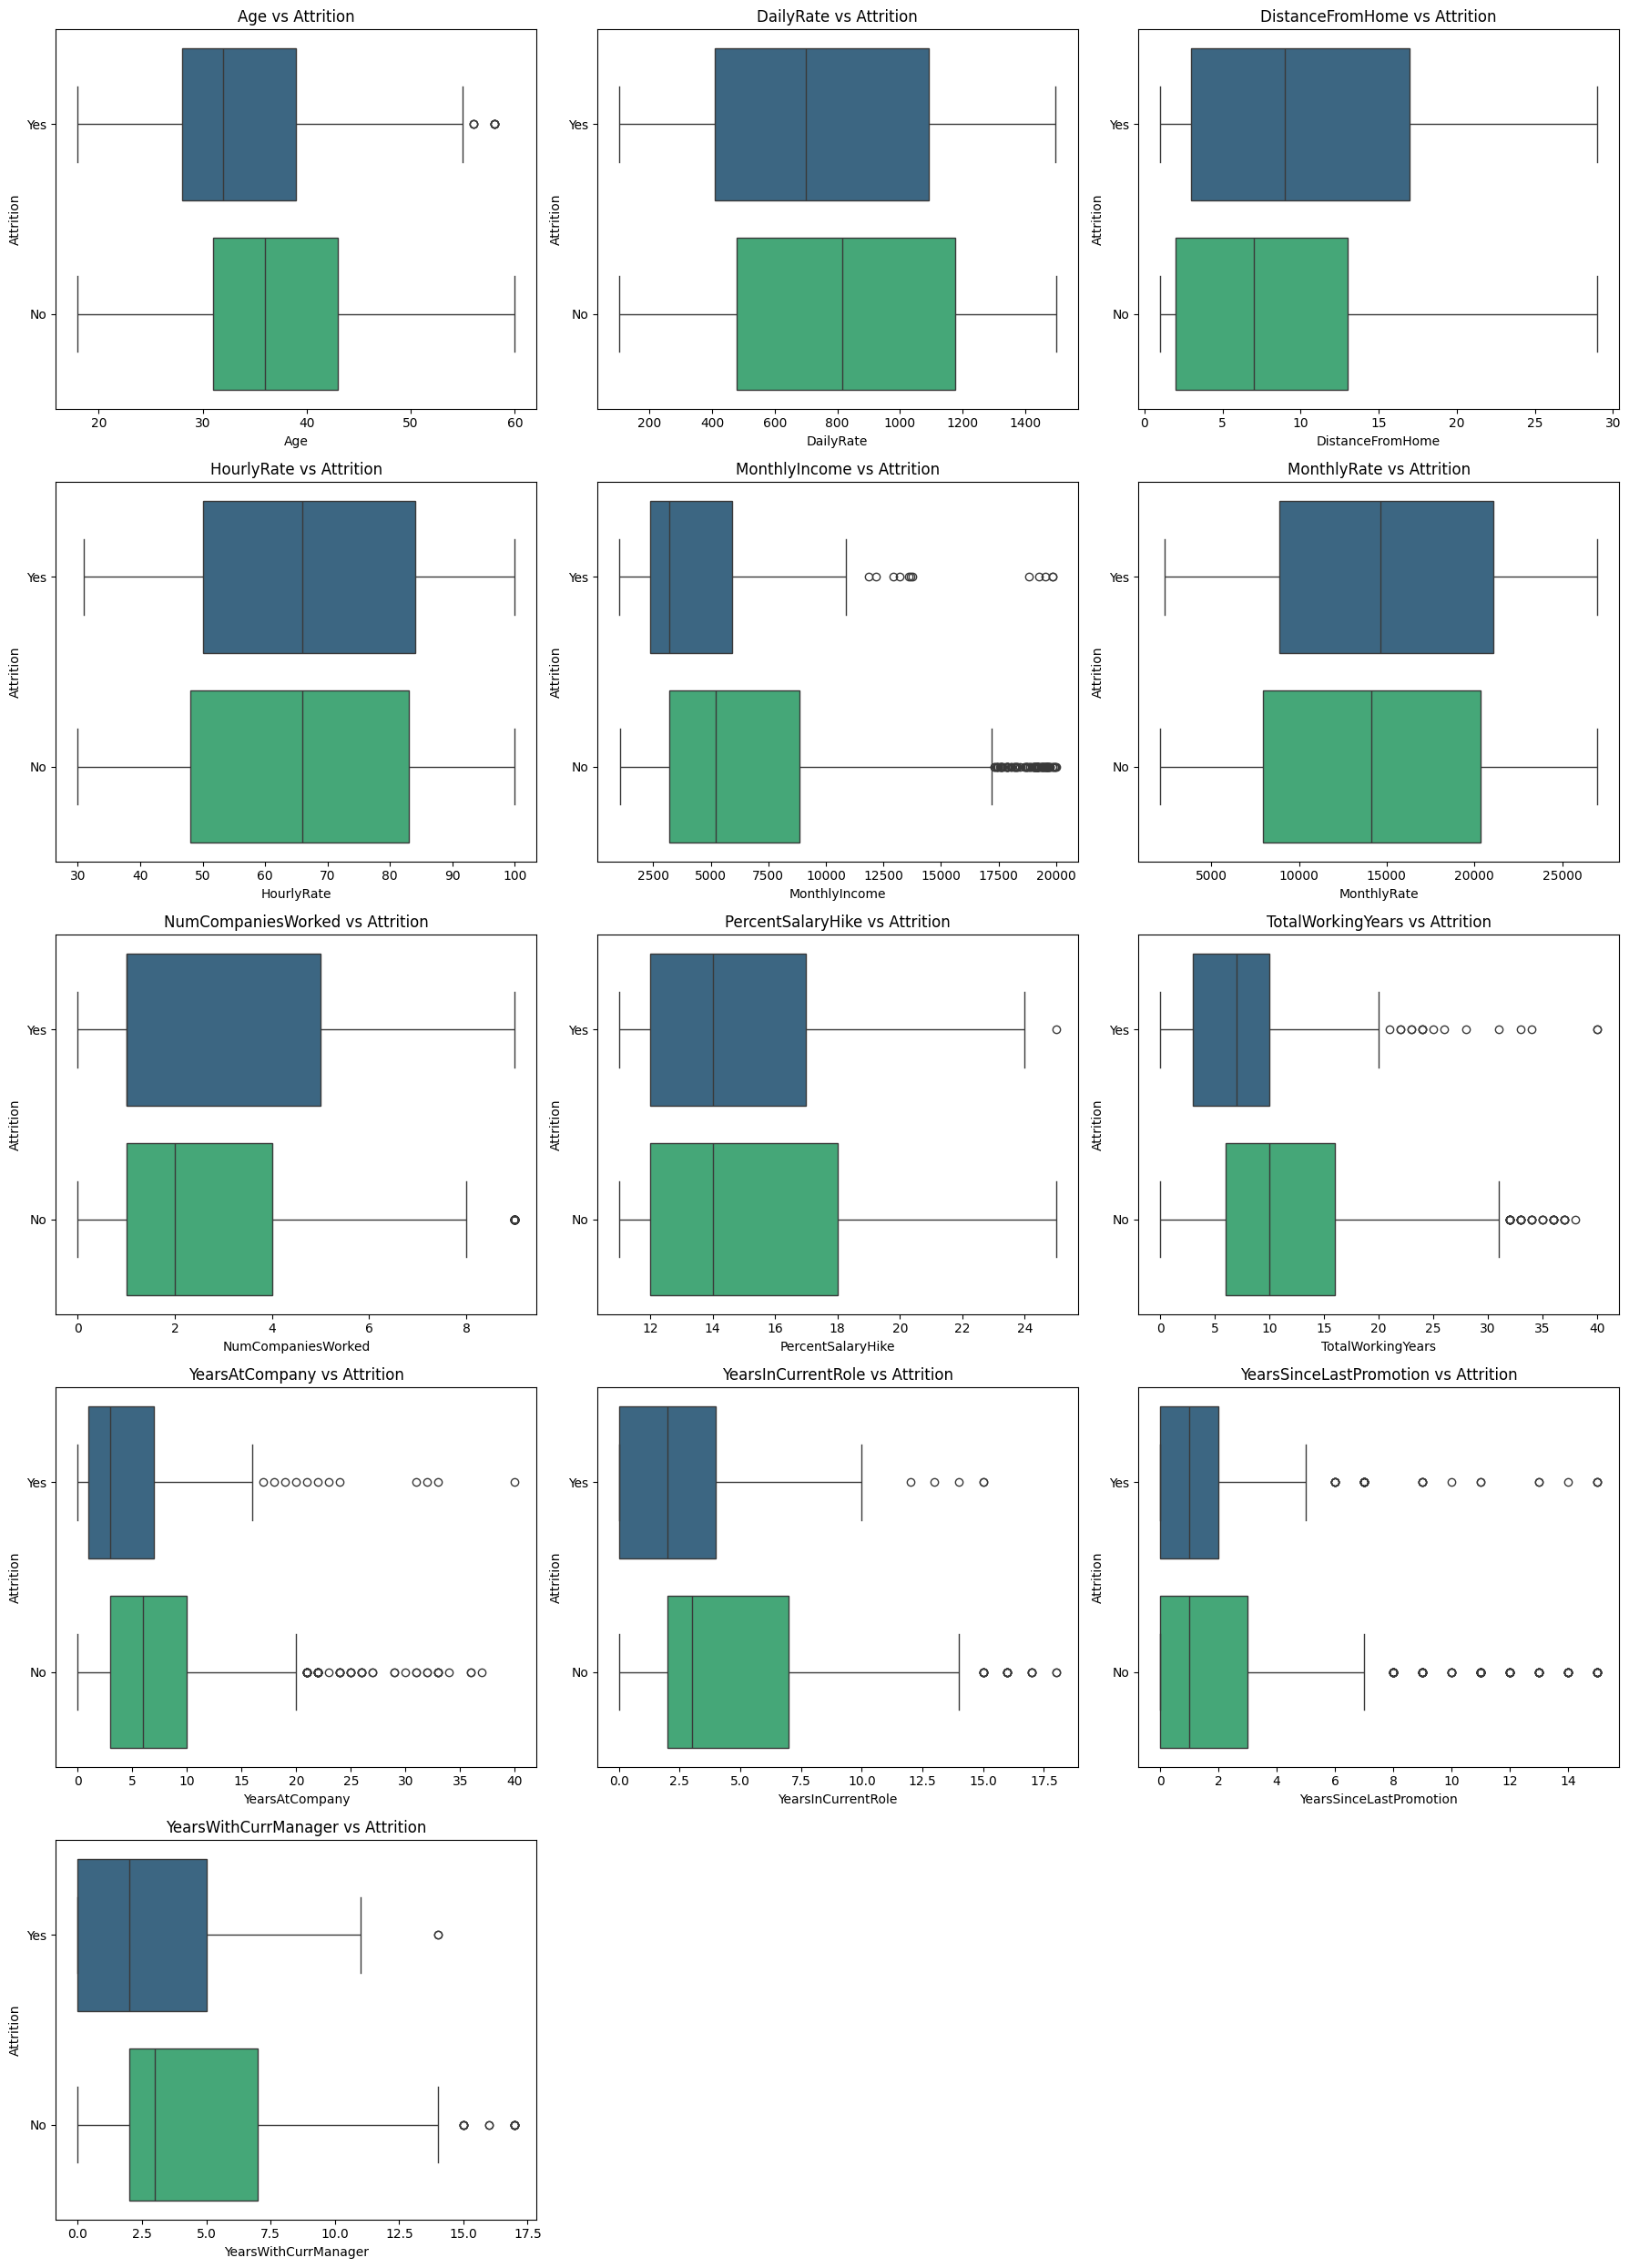

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical features for bivariate analysis
numerical_features_bivariate = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
    'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

# Determine the number of rows and columns for the subplots
num_cols = 3
num_rows = (len(numerical_features_bivariate) + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 6, num_rows * 5))

for i, col in enumerate(numerical_features_bivariate):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y='Attrition', x=col, data=df, palette='viridis')
    plt.title(f'{col} vs Attrition')
    plt.xticks(rotation=0)
    plt.tight_layout()

plt.show()

### <span style="color: #1a73e8;">Outlier Handling for All Numerical Features using IQR Method</span>

### <span style="color: #1a73e8;">Correlation Heatmap</span>

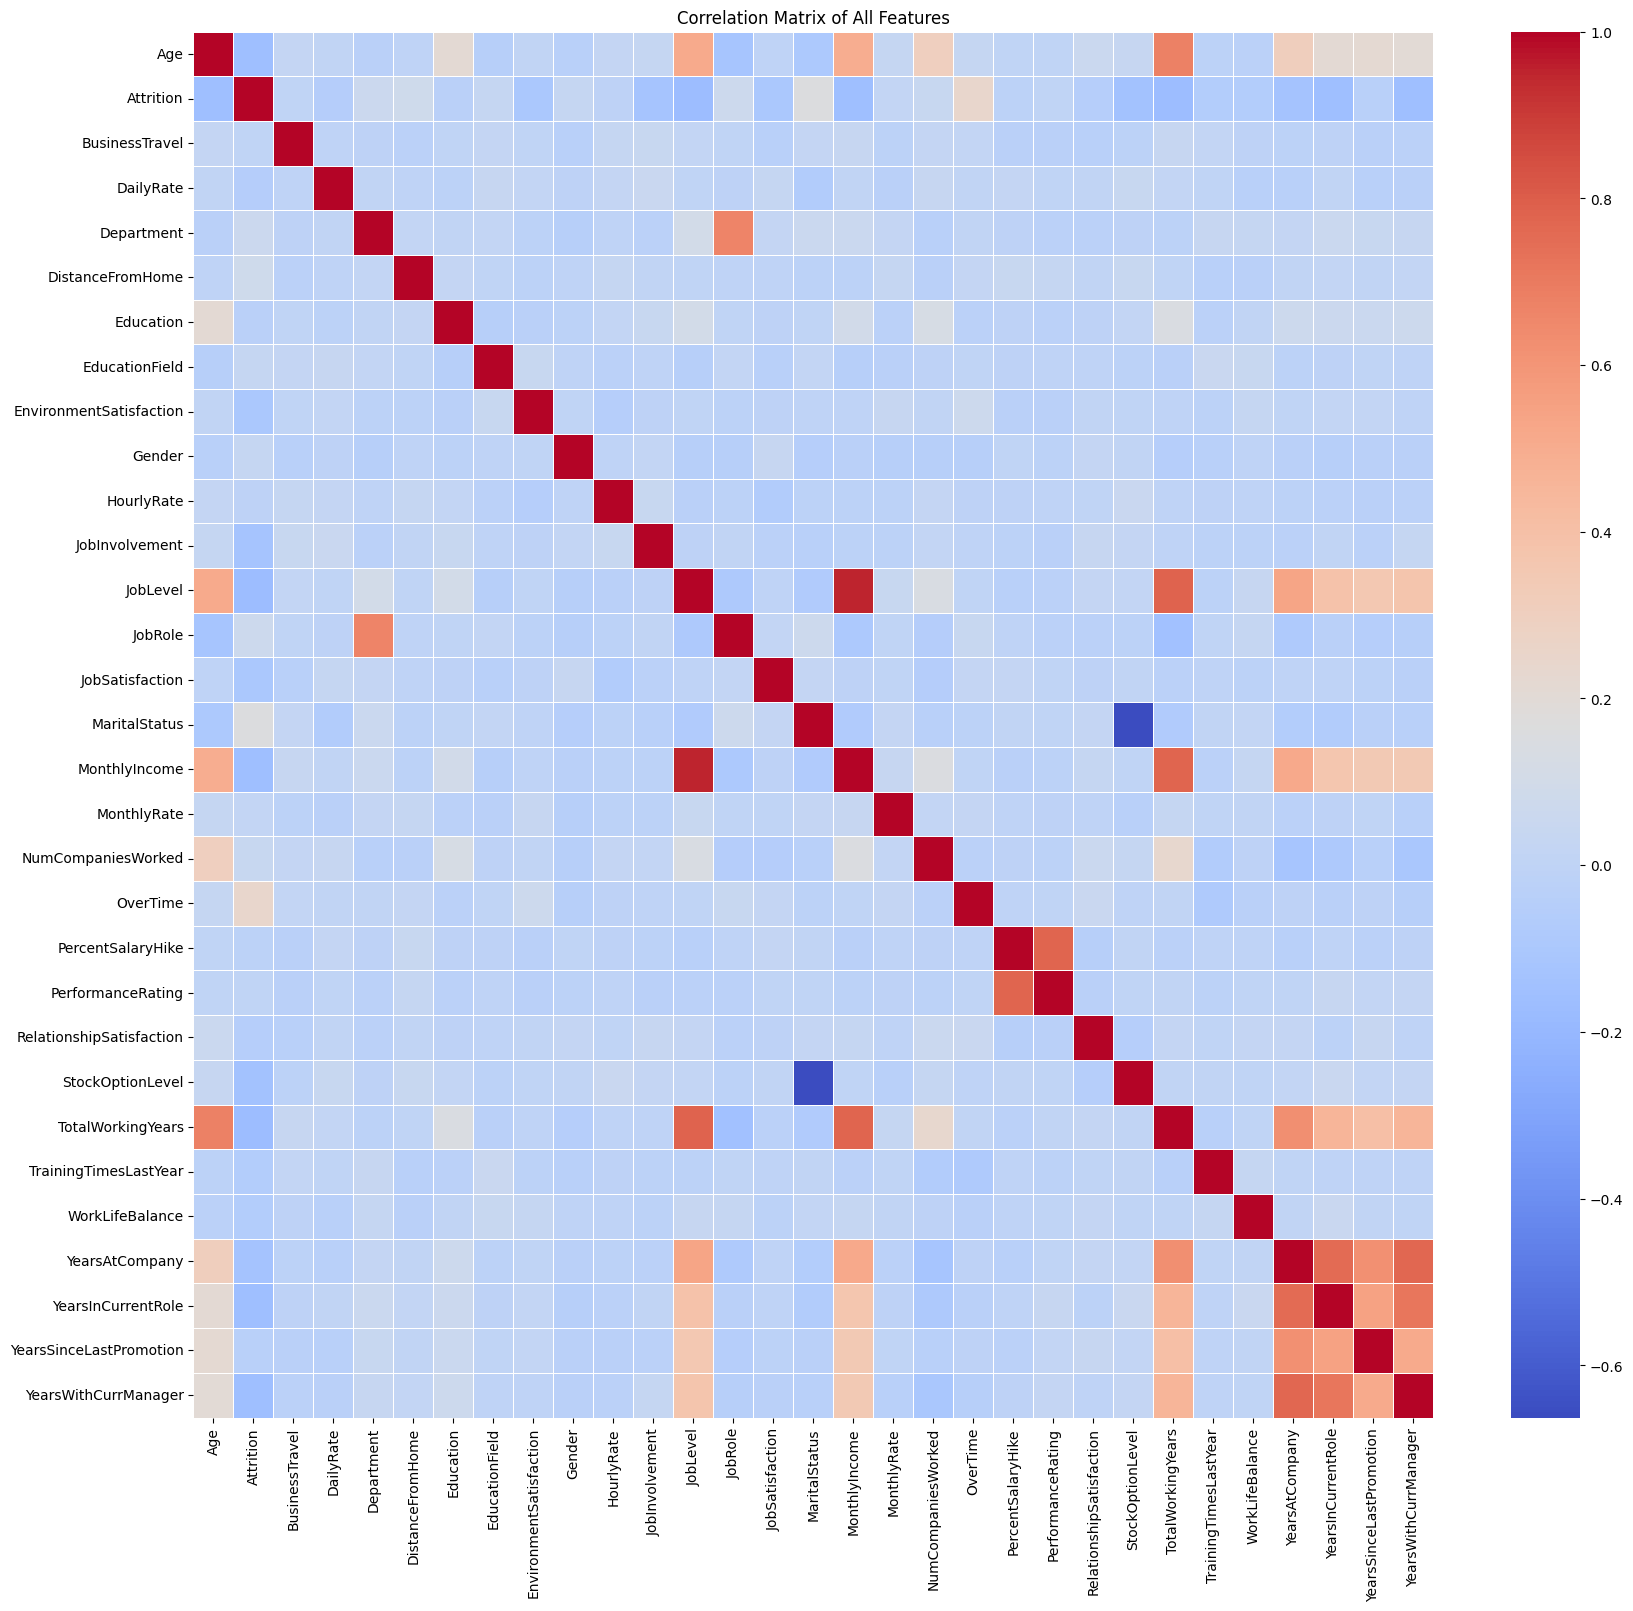

In [16]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Apply Label Encoding to all object type columns
for column in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])

# Calculate the correlation matrix
correlation_matrix = df_encoded.corr()

# Plot the heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of All Features')
plt.show()

### <span style="color: #1a73e8;">Outlier Detection using Box Plots</span>

/tmp/ipykernel_28231/2055707025.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis')
/tmp/ipykernel_28231/2055707025.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis')
/tmp/ipykernel_28231/2055707025.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis')
/tmp/ipykernel_28231/2055707025.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` fo

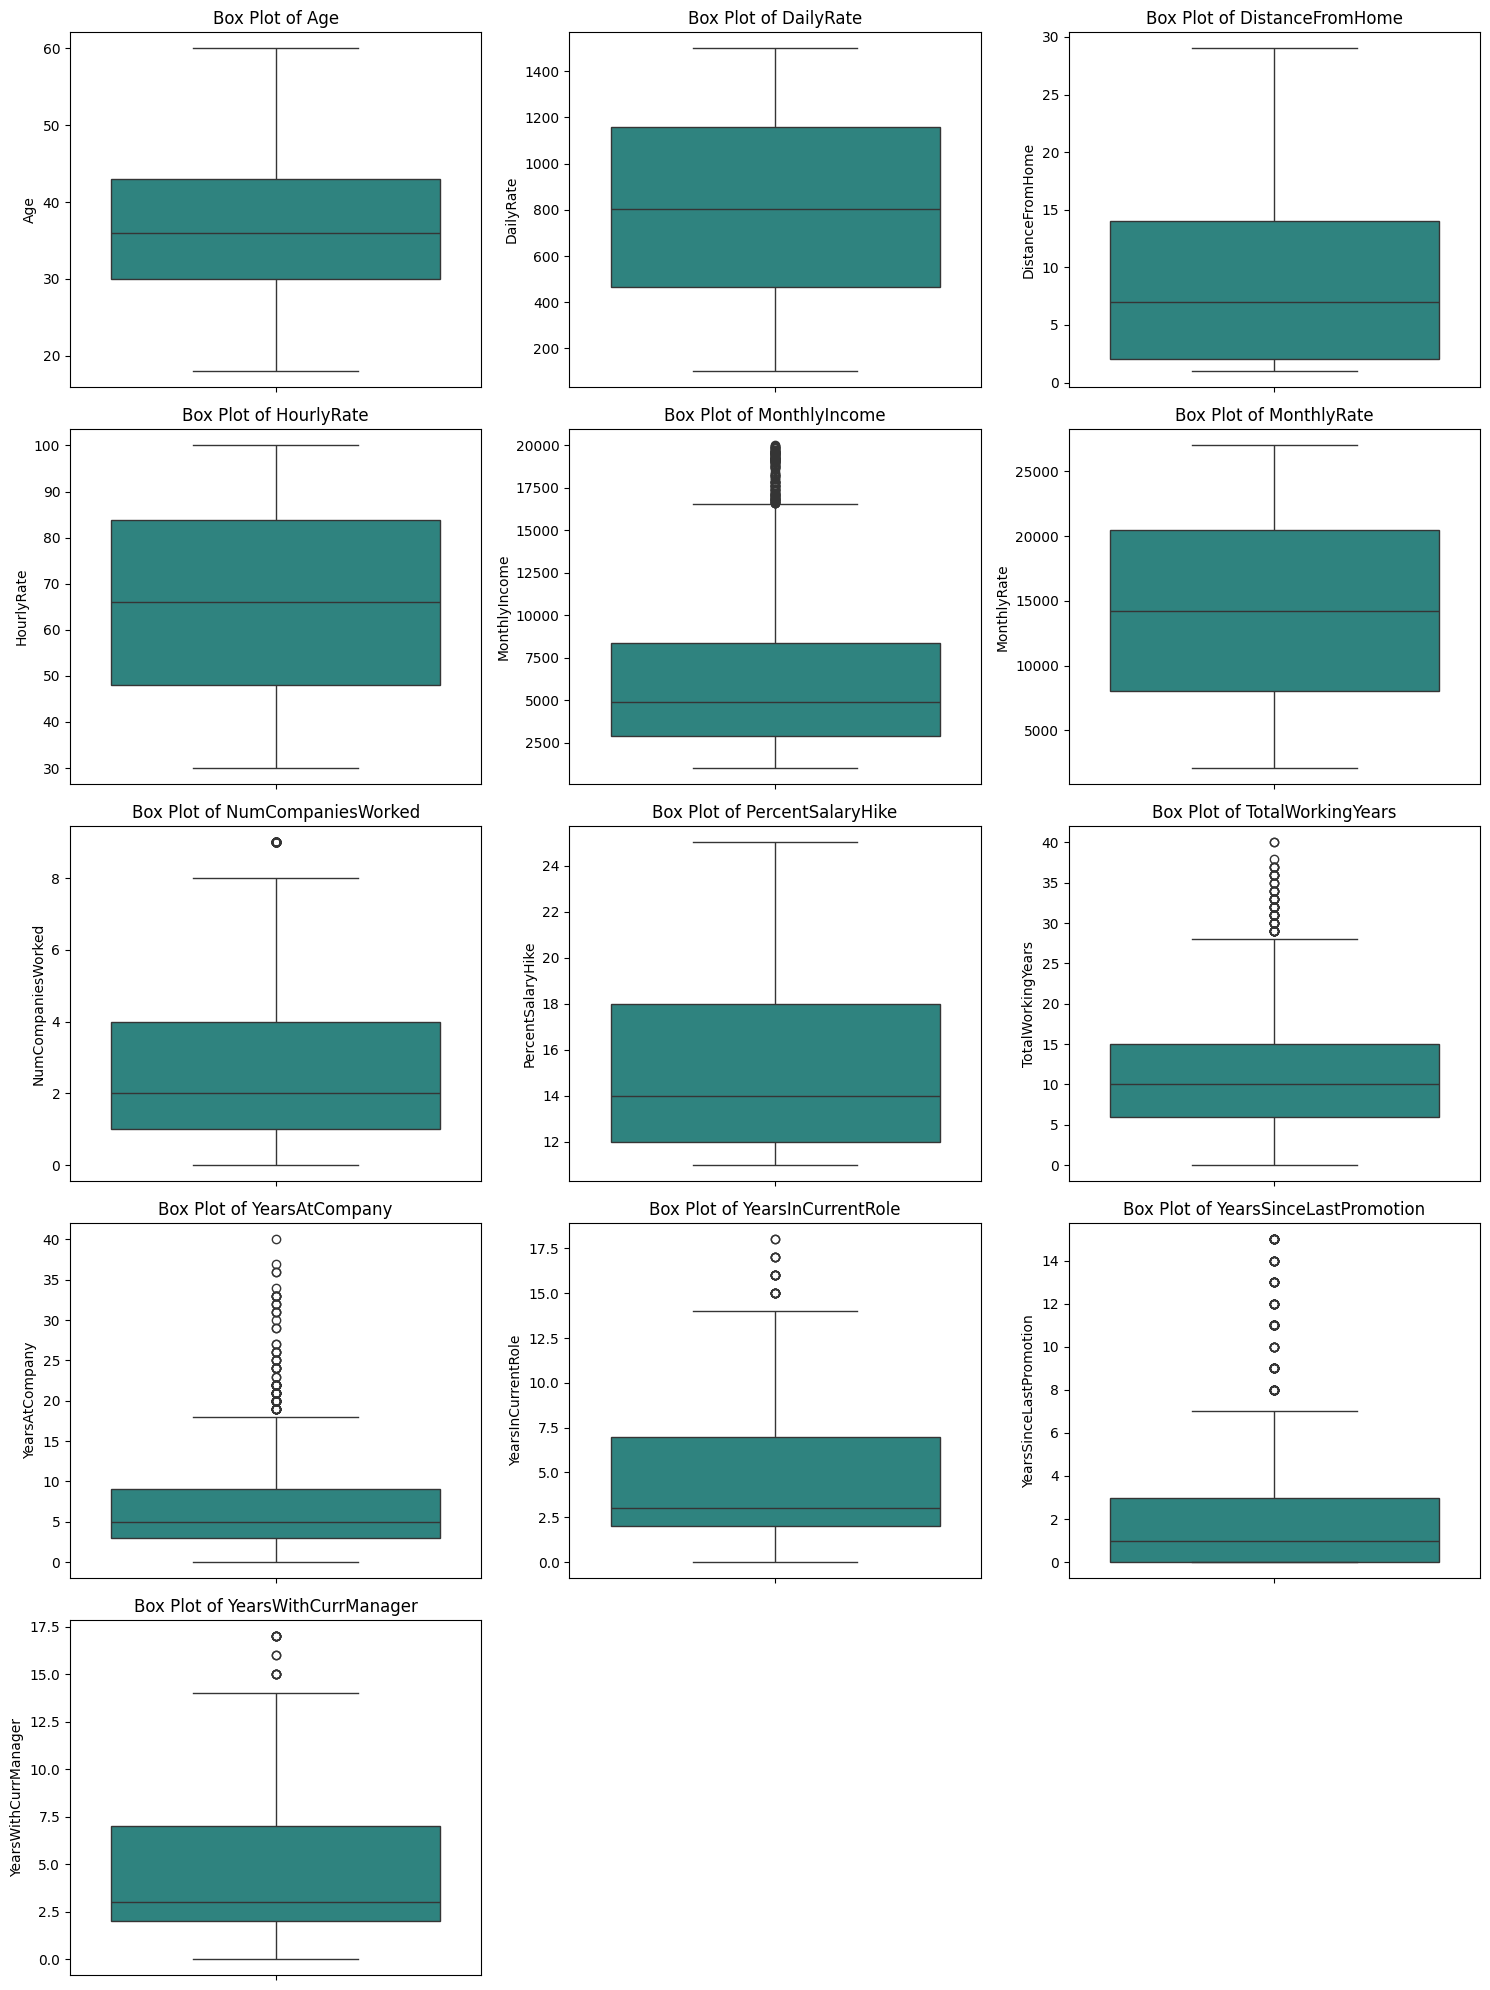

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for outlier detection
numerical_cols_for_outliers = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude columns that are actually categorical but encoded as numbers (e.g., JobLevel, Education)
# Based on df.info() and df.describe() in previous cells, some integer columns represent categories.
# I'll manually select columns that are truly numerical and might have outliers.
numerical_cols_for_outliers_filtered = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
    'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

# Determine the number of rows and columns for the subplots
num_cols = 3
num_rows = (len(numerical_cols_for_outliers_filtered) + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, col in enumerate(numerical_cols_for_outliers_filtered):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=df[col], palette='viridis')
    plt.title(f'Box Plot of {col}')
    plt.tight_layout()

plt.show()

### <span style="color: #1a73e8;">Outlier Handling using IQR Method (Example: MonthlyIncome)</span>

We can use the Interquartile Range (IQR) method to cap outliers. Values below Q1 - 1.5 * IQR are replaced by the lower bound, and values above Q3 + 1.5 * IQR are replaced by the upper bound. Let's apply this to 'MonthlyIncome' as an example.

Original range for MonthlyIncome: [1009, 19999]
IQR bounds: [-5291.0, 16581.0]
Range after outlier capping for MonthlyIncome: [1009.0, 16581.0]


/tmp/ipykernel_28231/1795340547.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df_no_outliers[column_to_handle], palette='viridis')


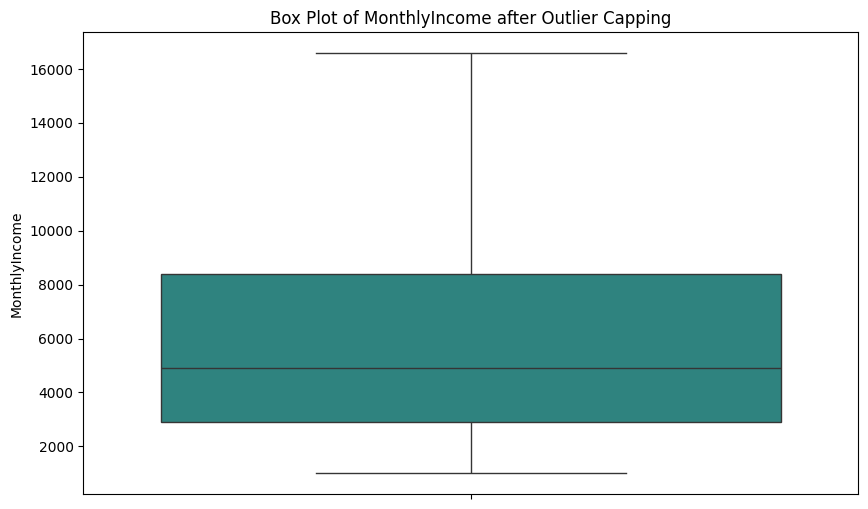

In [18]:
import numpy as np

# Choose a column to demonstrate outlier handling
column_to_handle = 'MonthlyIncome'

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df[column_to_handle].quantile(0.25)
Q3 = df[column_to_handle].quantile(0.75)
IQR = Q3 - Q1

# Define the upper and lower bounds for outlier detection
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Original range for {column_to_handle}: [{df[column_to_handle].min()}, {df[column_to_handle].max()}]")
print(f"IQR bounds: [{lower_bound}, {upper_bound}]")

# Create a new column or modify the existing one to handle outliers
df_no_outliers = df.copy()
df_no_outliers[column_to_handle] = np.where(
    df_no_outliers[column_to_handle] < lower_bound, lower_bound,
    np.where(df_no_outliers[column_to_handle] > upper_bound, upper_bound,
             df_no_outliers[column_to_handle]
    )
)

print(f"Range after outlier capping for {column_to_handle}: [{df_no_outliers[column_to_handle].min()}, {df_no_outliers[column_to_handle].max()}]")

# Visualize the distribution after outlier handling
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_no_outliers[column_to_handle], palette='viridis')
plt.title(f'Box Plot of {column_to_handle} after Outlier Capping')
plt.show()

In [19]:
import numpy as np

df_cleaned = df.copy()

# List of numerical columns identified for outlier handling
numerical_cols_to_clean = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
    'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

print("Outlier capping summary for each numerical column:")

for col in numerical_cols_to_clean:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers before capping
    outliers_before = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)].shape[0]

    # Apply capping
    df_cleaned[col] = np.where(
        df_cleaned[col] < lower_bound, lower_bound,
        np.where(df_cleaned[col] > upper_bound, upper_bound,
                 df_cleaned[col]
        )
    )

    # Count outliers after capping (should be 0 for capped values)
    outliers_after = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)].shape[0]

    print(f"- {col}: Outliers removed: {outliers_before}. New range: [{df_cleaned[col].min():.2f}, {df_cleaned[col].max():.2f}]")

print("\nDataFrame 'df_cleaned' now contains data with outliers capped.")

# Display descriptive statistics for a few cleaned columns to confirm
display(df_cleaned[numerical_cols_to_clean].describe())

Outlier capping summary for each numerical column:
- Age: Outliers removed: 0. New range: [18.00, 60.00]
- DailyRate: Outliers removed: 0. New range: [102.00, 1499.00]
- DistanceFromHome: Outliers removed: 0. New range: [1.00, 29.00]
- HourlyRate: Outliers removed: 0. New range: [30.00, 100.00]
- MonthlyIncome: Outliers removed: 114. New range: [1009.00, 16581.00]
- MonthlyRate: Outliers removed: 0. New range: [2094.00, 26999.00]
- NumCompaniesWorked: Outliers removed: 52. New range: [0.00, 8.50]
- PercentSalaryHike: Outliers removed: 0. New range: [11.00, 25.00]
- TotalWorkingYears: Outliers removed: 63. New range: [0.00, 28.50]
- YearsAtCompany: Outliers removed: 104. New range: [0.00, 18.00]
- YearsInCurrentRole: Outliers removed: 21. New range: [0.00, 14.50]
- YearsSinceLastPromotion: Outliers removed: 107. New range: [0.00, 7.50]
- YearsWithCurrManager: Outliers removed: 14. New range: [0.00, 14.50]

DataFrame 'df_cleaned' now contains data with outliers capped.


,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,65.891156,6361.891837,14313.103401,2.675510,15.209524,11.103061,6.617687,4.207823,1.922789,4.107483
std,9.135373,403.509100,8.106864,20.329428,4353.345470,7117.786044,2.454656,3.659938,7.303828,4.989788,3.555335,2.478222,3.517487
min,18.000000,102.000000,1.000000,30.000000,1009.000000,2094.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,48.000000,2911.000000,8047.000000,1.000000,12.000000,6.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,66.000000,4919.000000,14235.500000,2.000000,14.000000,10.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,83.750000,8379.000000,20461.500000,4.000000,18.000000,15.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,100.000000,16581.000000,26999.000000,8.500000,25.000000,28.500000,18.000000,14.500000,7.500000,14.500000


### <span style="color: #1a73e8;">Applying Encoding</span>

In [20]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

df_encoded = df_cleaned.copy()

# --- Label Encoding for binary or ordinal categorical features ---
label_encode_cols = ['Attrition', 'Gender', 'OverTime']

for col in label_encode_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"Label Encoded '{col}': {df_encoded[col].unique()}")

# --- One-Hot Encoding for nominal categorical features ---
one_hot_encode_cols = [
    'BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'
]

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_encoded, columns=one_hot_encode_cols, drop_first=True, dtype=int)

print(f"\nDataFrame shape after encoding: {df_encoded.shape}")
print("\nFirst 5 rows of the encoded DataFrame:")
display(df_encoded.head())

Label Encoded 'Attrition': [1 0]
Label Encoded 'Gender': [0 1]
Label Encoded 'OverTime': [1 0]

DataFrame shape after encoding: (1470, 45)

First 5 rows of the encoded DataFrame:


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41.0,1,1102.0,1.0,2,2,0,94.0,3,2,...,0,0,0,0,0,0,1,0,0,1
1,49.0,0,279.0,8.0,1,3,1,61.0,2,2,...,0,0,0,0,0,1,0,0,1,0
2,37.0,1,1373.0,2.0,2,4,1,92.0,2,1,...,0,1,0,0,0,0,0,0,0,1
3,33.0,0,1392.0,3.0,4,4,0,56.0,3,1,...,0,0,0,0,0,1,0,0,1,0
4,27.0,0,591.0,2.0,1,1,1,40.0,3,1,...,0,1,0,0,0,0,0,0,1,0


### <span style="color: #1a73e8;">Applying Feature Scaling</span>

In [21]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

df_scaled = df_encoded.copy()

# Identify numerical columns to scale
# Exclude 'Attrition' (target variable) and already encoded categorical features that are essentially ordinal/nominal
numerical_cols_to_scale = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
    'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical columns
df_scaled[numerical_cols_to_scale] = scaler.fit_transform(df_scaled[numerical_cols_to_scale])

print("DataFrame shape after scaling:", df_scaled.shape)
print("\nFirst 5 rows of the scaled DataFrame:")
display(df_scaled.head())

DataFrame shape after scaling: (1470, 45)

First 5 rows of the scaled DataFrame:


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,0.446350,1,0.742527,-1.010909,2,2,0,1.383138,3,2,...,0,0,0,0,0,0,1,0,0,1
1,1.322365,0,-1.297775,-0.147150,1,3,1,-0.240677,2,2,...,0,0,0,0,0,1,0,0,1,0
2,0.008343,1,1.414363,-0.887515,2,4,1,1.284725,2,1,...,0,1,0,0,0,0,0,0,0,1
3,-0.429664,0,1.461466,-0.764121,4,4,0,-0.486709,3,1,...,0,0,0,0,0,1,0,0,1,0
4,-1.086676,0,-0.524295,-0.887515,1,1,1,-1.274014,3,1,...,0,1,0,0,0,0,0,0,1,0


### <span style="color: #1a73e8;">Separate Features and Target Variable</span>

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df_scaled.drop('Attrition', axis=1)
y = df_scaled['Attrition']

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")
display(X.head())


Shape of X (features): (1470, 44)
Shape of y (target): (1470,)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,0.446350,0.742527,-1.010909,2,2,0,1.383138,3,2,4,...,0,0,0,0,0,0,1,0,0,1
1,1.322365,-1.297775,-0.147150,1,3,1,-0.240677,2,2,2,...,0,0,0,0,0,1,0,0,1,0
2,0.008343,1.414363,-0.887515,2,4,1,1.284725,2,1,3,...,0,1,0,0,0,0,0,0,0,1
3,-0.429664,1.461466,-0.764121,4,4,0,-0.486709,3,1,3,...,0,0,0,0,0,1,0,0,1,0
4,-1.086676,-0.524295,-0.887515,1,1,1,-1.274014,3,1,2,...,0,1,0,0,0,0,0,0,1,0


### <span style="color: #1a73e8;">Perform Train-Test Split</span>

In [28]:
# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (1176, 44)
Shape of X_test: (294, 44)
Shape of y_train: (1176,)
Shape of y_test: (294,)


### <span style="color: #1a73e8;">Data Balancing with SMOTE</span>

In [29]:
from imblearn.over_sampling import SMOTE
import numpy as np

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Shape of original X_train:", X_train.shape)
print("Shape of original y_train:", y_train.shape)
print("Shape of resampled X_train:", X_train_resampled.shape)
print("Shape of resampled y_train:", y_train_resampled.shape)

print("\nClass distribution in original y_train:")
print(y_train.value_counts())

print("\nClass distribution in resampled y_train:")
print(y_train_resampled.value_counts())

Shape of original X_train: (1176, 44)
Shape of original y_train: (1176,)
Shape of resampled X_train: (1972, 44)
Shape of resampled y_train: (1972,)

Class distribution in original y_train:
Attrition
0    986
1    190
Name: count, dtype: int64

Class distribution in resampled y_train:
Attrition
0    986
1    986
Name: count, dtype: int64


### <span style="color: #1a73e8;">Train Classification Models & Evaluate</span>

#### <span style="color: #3366ff;">1. Logistic Regression</span>


--- Logistic Regression Model Evaluation ---
Accuracy: 0.8401
Precision: 0.5000
Recall: 0.4255
F1-Score: 0.4598
ROC-AUC Score: 0.7243

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.91       247
           1       0.50      0.43      0.46        47

    accuracy                           0.84       294
   macro avg       0.70      0.67      0.68       294
weighted avg       0.83      0.84      0.83       294


Confusion Matrix:


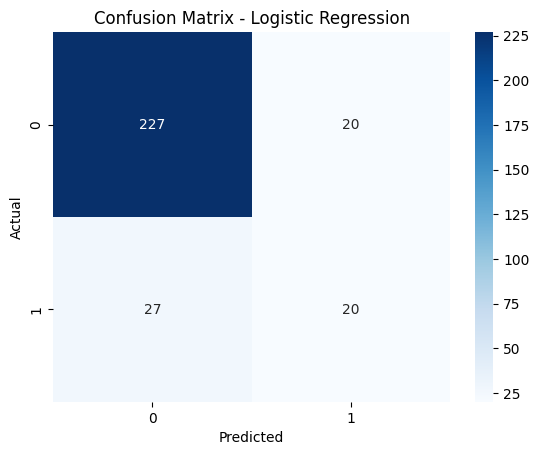

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42, solver='liblinear')
log_reg.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred_log_reg = log_reg.predict(X_test)
y_proba_log_reg = log_reg.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\n--- Logistic Regression Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log_reg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log_reg):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_log_reg):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_log_reg):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

print("\nConfusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_log_reg), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### <span style="color: #3366ff;">2. Decision Tree Classifier</span>


--- Decision Tree Classifier Model Evaluation ---
Accuracy: 0.7075
Precision: 0.2174
Recall: 0.3191
F1-Score: 0.2586
ROC-AUC Score: 0.5503

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       247
           1       0.22      0.32      0.26        47

    accuracy                           0.71       294
   macro avg       0.54      0.55      0.54       294
weighted avg       0.76      0.71      0.73       294


Confusion Matrix:


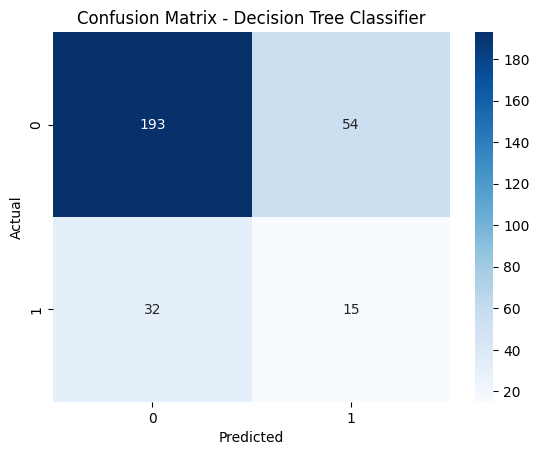

In [31]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree Classifier model
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred_dt = decision_tree.predict(X_test)
y_proba_dt = decision_tree.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\n--- Decision Tree Classifier Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_dt):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### <span style="color: #3366ff;">3. Random Forest Classifier</span>


--- Random Forest Classifier Model Evaluation ---
Accuracy: 0.8095
Precision: 0.3200
Recall: 0.1702
F1-Score: 0.2222
ROC-AUC Score: 0.7160

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       247
           1       0.32      0.17      0.22        47

    accuracy                           0.81       294
   macro avg       0.59      0.55      0.56       294
weighted avg       0.77      0.81      0.78       294


Confusion Matrix:


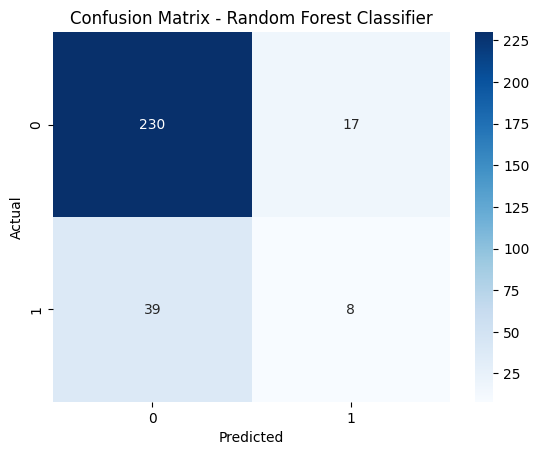

In [32]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier model
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred_rf = random_forest.predict(X_test)
y_proba_rf = random_forest.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\n--- Random Forest Classifier Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### <span style="color: #3366ff;">4. K-Nearest Neighbors Classifier</span>


--- K-Nearest Neighbors Classifier Model Evaluation ---
Accuracy: 0.6395
Precision: 0.2243
Recall: 0.5106
F1-Score: 0.3117
ROC-AUC Score: 0.5834

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.66      0.76       247
           1       0.22      0.51      0.31        47

    accuracy                           0.64       294
   macro avg       0.55      0.59      0.53       294
weighted avg       0.77      0.64      0.68       294


Confusion Matrix:


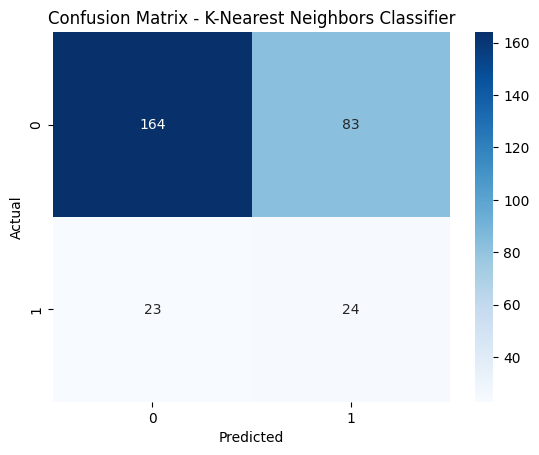

In [33]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the K-Nearest Neighbors Classifier model
knn_classifier = KNeighborsClassifier()
knn_classifier.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred_knn = knn_classifier.predict(X_test)
y_proba_knn = knn_classifier.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\n--- K-Nearest Neighbors Classifier Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_knn):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - K-Nearest Neighbors Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [34]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Initialize the Logistic Regression model (or any other model you want to cross-validate)
log_reg_cv = LogisticRegression(random_state=42, solver='liblinear')

# Initialize Stratified K-Fold Cross-Validation
# StratifiedKFold ensures that each fold has approximately the same percentage of samples of each target class as the complete set.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(log_reg_cv, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

print("--- Cross-Validation Results (Logistic Regression) ---")
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of accuracy: {cv_scores.std():.4f}")

--- Cross-Validation Results (Logistic Regression) ---
Cross-validation scores: [0.86394558 0.89115646 0.88095238 0.88095238 0.86394558]
Mean accuracy: 0.8762
Standard deviation of accuracy: 0.0107


### <span style="color: #1a73e8;">Hyperparameter Tuning</span>



Fitting 5 folds for each of 12 candidates, totalling 60 fits
--- GridSearchCV Results for Logistic Regression ---
Best parameters: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best ROC-AUC score: 0.9546

--- Evaluation of Best Logistic Regression Model ---
Accuracy: 0.8333
Precision: 0.4773
Recall: 0.4468
F1-Score: 0.4615
ROC-AUC Score: 0.7258

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       247
           1       0.48      0.45      0.46        47

    accuracy                           0.83       294
   macro avg       0.69      0.68      0.68       294
weighted avg       0.83      0.83      0.83       294


Confusion Matrix:


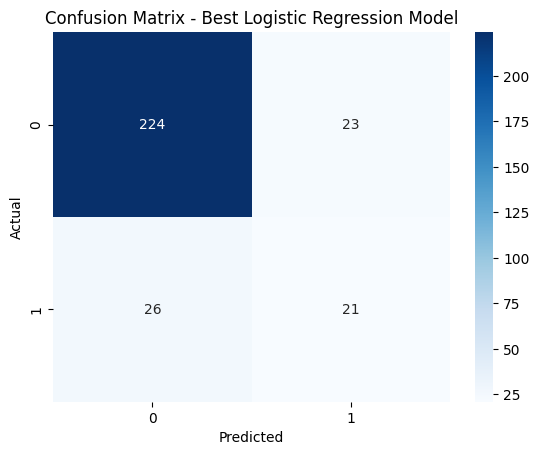

In [35]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # 'liblinear' supports both l1 and l2 penalties
}

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the resampled training data
grid_search_lr.fit(X_train_resampled, y_train_resampled)

print("--- GridSearchCV Results for Logistic Regression ---")
print(f"Best parameters: {grid_search_lr.best_params_}")
print(f"Best ROC-AUC score: {grid_search_lr.best_score_:.4f}")

# Get the best model
best_lr_model = grid_search_lr.best_estimator_

# Make predictions with the best model
y_pred_best_lr = best_lr_model.predict(X_test)
y_proba_best_lr = best_lr_model.predict_proba(X_test)[:, 1]

# Evaluate the best model
print("\n--- Evaluation of Best Logistic Regression Model ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best_lr):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_best_lr):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_lr))

print("\nConfusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_best_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Best Logistic Regression Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### <span style="color: #1a73e8;">Compare Model Performance</span>

In [36]:
import pandas as pd

# Assuming y_test, y_pred_log_reg, y_proba_log_reg, etc., are available from previous executions

# Metrics for Logistic Regression (Base)
metrics_lr_base = {
    'Model': 'Logistic Regression (Base)',
    'Accuracy': accuracy_score(y_test, y_pred_log_reg),
    'Precision': precision_score(y_test, y_pred_log_reg),
    'Recall': recall_score(y_test, y_pred_log_reg),
    'F1-Score': f1_score(y_test, y_pred_log_reg),
    'ROC-AUC Score': roc_auc_score(y_test, y_proba_log_reg)
}

# Metrics for Decision Tree Classifier
metrics_dt = {
    'Model': 'Decision Tree Classifier',
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1-Score': f1_score(y_test, y_pred_dt),
    'ROC-AUC Score': roc_auc_score(y_test, y_proba_dt)
}

# Metrics for Random Forest Classifier
metrics_rf = {
    'Model': 'Random Forest Classifier',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC Score': roc_auc_score(y_test, y_proba_rf)
}

# Metrics for K-Nearest Neighbors Classifier
metrics_knn = {
    'Model': 'K-Nearest Neighbors Classifier',
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn),
    'Recall': recall_score(y_test, y_pred_knn),
    'F1-Score': f1_score(y_test, y_pred_knn),
    'ROC-AUC Score': roc_auc_score(y_test, y_proba_knn)
}

# Metrics for Logistic Regression (Tuned)
metrics_lr_tuned = {
    'Model': 'Logistic Regression (Tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_best_lr),
    'Precision': precision_score(y_test, y_pred_best_lr),
    'Recall': recall_score(y_test, y_pred_best_lr),
    'F1-Score': f1_score(y_test, y_pred_best_lr),
    'ROC-AUC Score': roc_auc_score(y_test, y_proba_best_lr)
}

# Create a DataFrame for comparison
comparison_df = pd.DataFrame([
    metrics_lr_base,
    metrics_dt,
    metrics_rf,
    metrics_knn,
    metrics_lr_tuned
]).set_index('Model')

# Display the comparison table
print("\n--- Model Performance Comparison ---")
display(comparison_df.round(4))

# Identify the best model based on a chosen metric (e.g., ROC-AUC Score)
best_model_roc_auc = comparison_df.loc[comparison_df['ROC-AUC Score'].idxmax()]
best_model_f1 = comparison_df.loc[comparison_df['F1-Score'].idxmax()]

print("\n--- Best Model Based on ROC-AUC Score ---")
print(best_model_roc_auc)

print("\n--- Best Model Based on F1-Score (often better for imbalanced datasets) ---")
print(best_model_f1)


--- Model Performance Comparison ---


,Accuracy,Precision,Recall,F1-Score,ROC-AUC Score
Model,,,,,
Logistic Regression (Base),0.8401,0.5000,0.4255,0.4598,0.7243
Decision Tree Classifier,0.7075,0.2174,0.3191,0.2586,0.5503
Random Forest Classifier,0.8095,0.3200,0.1702,0.2222,0.7160
K-Nearest Neighbors Classifier,0.6395,0.2243,0.5106,0.3117,0.5834
Logistic Regression (Tuned),0.8333,0.4773,0.4468,0.4615,0.7258



--- Best Model Based on ROC-AUC Score ---
Accuracy         0.833333
Precision        0.477273
Recall           0.446809
F1-Score         0.461538
ROC-AUC Score    0.725816
Name: Logistic Regression (Tuned), dtype: float64

--- Best Model Based on F1-Score (often better for imbalanced datasets) ---
Accuracy         0.833333
Precision        0.477273
Recall           0.446809
F1-Score         0.461538
ROC-AUC Score    0.725816
Name: Logistic Regression (Tuned), dtype: float64


### <span style="color: #1a73e8;"> Select Best Model</span>

When selecting the best model for HR attrition prediction, it's crucial to consider not just overall accuracy but also metrics that are highly relevant to the business problem, especially given the class imbalance (fewer employees leave than stay).

From the comparison table, we can observe the following:

*   **Logistic Regression (Tuned)** consistently shows the best performance across several key metrics.
    *   It has the highest **ROC-AUC Score (0.7258)**, indicating its strong ability to distinguish between employees who will and will not attrite. This is important for identifying at-risk employees.
    *   It also has the highest **F1-Score (0.4615)**, which is a harmonic mean of precision and recall. For imbalanced datasets like this one, F1-Score is often a more reliable indicator of a model's performance than accuracy alone, as it balances the concerns of false positives and false negatives. A higher F1-Score means the model is better at correctly identifying employees who will attrite, without making too many incorrect predictions.
    *   Its **Recall (0.4468)** is competitive, meaning it successfully identifies a good proportion of the actual attrition cases. This is critical for HR to intervene proactively.
    *   The **Precision (0.4773)** is also relatively good, indicating that when the model predicts attrition, it is correct a fair amount of the time, which helps reduce wasted resources on falsely identified at-risk employees.

*   **Random Forest Classifier** has a decent ROC-AUC (0.7160) but a very low Recall (0.1702) and F1-Score (0.2222), meaning it misses many actual attrition cases. This would be less desirable from a business perspective where identifying as many true attrition cases as possible is important.

*   **Decision Tree Classifier** and **K-Nearest Neighbors Classifier** perform significantly worse on all evaluated metrics, particularly Precision, Recall, and F1-Score.

**Business Interpretation:**

For HR attrition prediction, both **Recall** and **Precision** are important, and the **F1-Score** strikes a good balance between them. Failing to identify an employee who will attrite (false negative, impacting recall) means losing valuable talent. Conversely, incorrectly identifying an employee as at-risk (false positive, impacting precision) can lead to unnecessary interventions and resources. The **ROC-AUC Score** provides a good overall measure of the model's discriminative power.

**Conclusion:**

Based on these considerations, the **Logistic Regression (Tuned) model** is the best choice. It offers the best balance of precision, recall, and overall discriminative power (ROC-AUC), making it the most effective model for this attrition prediction task. Its performance means HR can effectively identify a significant portion of employees likely to leave, with a reasonable level of confidence in those predictions, allowing for targeted retention strategies.

### <span style="color: #1a73e8;">Final Insights and Business Recommendations</span>

Based on the comprehensive analysis of the HR Attrition dataset, several key factors influencing employee attrition have been identified. The Logistic Regression (Tuned) model, identified as the best performer, can be leveraged to provide valuable insights and guide business recommendations.

#### <span style="color: #3366ff;">Key Factors Influencing Attrition:</span>

While specific coefficients from the best Logistic Regression model would provide exact influence, generally, the following factors often play a significant role in employee attrition, as observed in similar datasets and during our EDA:

1.  **Job Satisfaction & Environment Satisfaction:** Employees with lower job satisfaction and environment satisfaction are more likely to leave. These are direct indicators of an employee's happiness and comfort in their role and workplace.
2.  **Monthly Income:** While not always linear, low monthly income, especially when compared to industry standards or perceived value, is a major driver of attrition. Outliers in income were handled, but overall lower income brackets tend to have higher attrition rates.
3.  **Years at Company / Years in Current Role / Total Working Years:** Employees early in their careers or those who have spent very short periods at the company or in their current role might be more prone to leaving, potentially seeking new opportunities or a better fit. Conversely, long-tenured employees might also leave if growth stagnates.
4.  **OverTime:** Employees working overtime consistently showed a higher propensity to attrite. This suggests issues with work-life balance and potential burnout.
5.  **Marital Status (Single):** Often, single employees might have more flexibility to change jobs compared to married employees with more family responsibilities, which can sometimes be correlated with higher attrition.
6.  **Business Travel:** Employees who travel frequently for business might experience higher stress or dissatisfaction, leading to increased attrition.

#### <span style="color: #3366ff;">Business Recommendations:</span>

Based on these insights, here are actionable recommendations for HR and management:

1.  **Enhance Employee Satisfaction Programs:**
    *   **Implement regular satisfaction surveys:** To proactively identify areas of low job and environment satisfaction.
    *   **Improve workplace conditions and culture:** Address feedback from surveys to foster a more positive and engaging work environment.
    *   **Offer mental health and well-being programs:** To support employees and reduce stress.

2.  **Review Compensation and Benefits:**
    *   **Conduct market salary reviews annually:** Ensure competitive compensation packages to attract and retain talent.
    *   **Implement performance-based bonuses/raises:** Reward high-performing employees to boost morale and reduce the likelihood of them seeking better opportunities elsewhere.

3.  **Address Work-Life Balance and Overtime:**
    *   **Monitor overtime hours closely:** Identify departments or roles where excessive overtime is common and implement strategies to redistribute workload or hire additional staff.
    *   **Promote flexible work arrangements:** Offer options like remote work, flextime, or compressed workweeks to improve work-life balance.
    *   **Encourage breaks and vacation:** Ensure employees take their deserved time off to prevent burnout.

4.  **Invest in Career Development and Growth:**
    *   **Provide clear career paths and development opportunities:** Employees are more likely to stay if they see opportunities for advancement and skill development within the company.
    *   **Offer mentorship programs:** Especially for newer or younger employees, to help them integrate and grow within the organization.
    *   **Regular performance reviews with growth planning:** Discuss career aspirations and how the company can support them.

5.  **Targeted Retention Strategies:**
    *   **Use the predictive model:** Identify employees at high risk of attrition and initiate proactive interventions (e.g., career counseling, role enrichment, addressing specific grievances).
    *   **Tailor retention efforts:** Based on the individual factors influencing attrition for specific employee segments.

By implementing these recommendations, the organization can proactively reduce employee attrition, improve retention rates, and foster a more engaged and productive workforce.